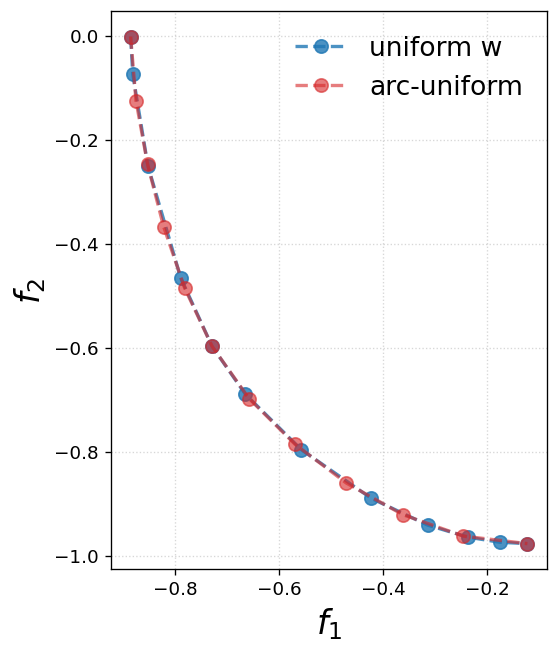

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import random

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()
torch.set_default_dtype(torch.float64)


# ============================================================
# 1) Singleton-state bandit
# ============================================================
A = 5
x = torch.linspace(0.0, 1.0, A)
alpha_curve = 4.0

# True mean rewards: R_1(a), R_2(a)
R1_true = x
R2_true = 1.0 - x**alpha_curve

# Reference policy and R0 = log(pi_ref)
pi_ref = torch.ones(A, dtype=torch.float64) / A
eps = 1e-12
R0 = torch.log(torch.clamp(pi_ref, eps, 1.0))

# ============================================================
# 2) Reward model
# ============================================================
def sample_reward(a, noise_std=0.1):
    noise1 = torch.randn(1).item() * noise_std
    noise2 = torch.randn(1).item() * noise_std
    return R1_true[a].item() + noise1, R2_true[a].item() + noise2

# ============================================================
# 3) Build one fixed offline dataset
#    Guarantee every arm is sampled at least once
# ============================================================
def build_offline_dataset(T=50000, noise_std=0.1, mode="balanced"):
    """
    Build a fixed offline dataset:
        D = {(a_t, r1_t, r2_t)}_{t=1}^T

    mode:
        "balanced" : each arm appears roughly equally often
        "uniform_once_then_random" : first one sample per arm, then random
    """
    if T < A:
        raise ValueError(f"T must be at least A={A} so every arm is sampled at least once.")

    if mode == "balanced":
        repeats = T // A
        remainder = T % A

        actions = np.repeat(np.arange(A), repeats)

        if remainder > 0:
            extra = np.random.choice(A, size=remainder, replace=False)
            actions = np.concatenate([actions, extra])

        np.random.shuffle(actions)

    elif mode == "uniform_once_then_random":
        actions = list(range(A))
        remaining = T - A
        if remaining > 0:
            extra = np.random.choice(A, size=remaining, replace=True)
            actions.extend(extra.tolist())
        actions = np.array(actions)
        np.random.shuffle(actions)

    else:
        raise ValueError("mode must be 'balanced' or 'uniform_once_then_random'")

    rewards1 = np.zeros(len(actions))
    rewards2 = np.zeros(len(actions))

    for t, a in enumerate(actions):
        r1_s, r2_s = sample_reward(a, noise_std=noise_std)
        rewards1[t] = r1_s
        rewards2[t] = r2_s

    return actions, rewards1, rewards2

# ============================================================
# 4) Estimate empirical means from the fixed offline dataset
# ============================================================
def estimate_reward_means(actions, rewards1, rewards2):
    sum_R1 = torch.zeros(A, dtype=torch.float64)
    sum_R2 = torch.zeros(A, dtype=torch.float64)
    N = torch.zeros(A, dtype=torch.float64)

    for t in range(len(actions)):
        a = int(actions[t])
        sum_R1[a] += rewards1[t]
        sum_R2[a] += rewards2[t]
        N[a] += 1

    R1_hat = sum_R1 / N
    R2_hat = sum_R2 / N
    return R1_hat, R2_hat, N, sum_R1, sum_R2

# ============================================================
# 5) Closed-form policy
# ============================================================
def softmax_policy(R1_hat, R2_hat, w, tau=0.05, R0_vec=None):
    if R0_vec is None:
        R0_vec = torch.zeros_like(R1_hat)
    logits = R0_vec + (w * R1_hat + (1.0 - w) * R2_hat) / tau
    return torch.softmax(logits, dim=0)

# ============================================================
# 6) Min-problem objectives
# ============================================================
def f_components_policy(pi, R1_eval, R2_eval, tau=0.05, pi_ref_vec=None):
    if pi_ref_vec is None:
        pi_ref_vec = torch.ones_like(pi) / len(pi)

    eps = 1e-12
    pi_c = torch.clamp(pi, eps, 1.0)
    pref_c = torch.clamp(pi_ref_vec, eps, 1.0)

    kl = torch.sum(pi_c * (torch.log(pi_c) - torch.log(pref_c)))
    f1 = tau * kl - torch.sum(pi * R1_eval)
    f2 = tau * kl - torch.sum(pi * R2_eval)
    return f1.item(), f2.item()

# ============================================================
# 7) Explicit speed formula
#
#    v_w(w)
#    = tau^{-1} sqrt((1-w)^2 + w^2)
#      (R1-R2)^T (Diag(x_w)-x_w x_w^T) (R1-R2)
#
#    Here we use the plug-in version with estimated rewards.
# ============================================================
def explicit_speed_from_policy(pi_w, R1_eval, R2_eval, w, tau=0.05):
    delta = (R1_eval - R2_eval).reshape(-1, 1)
    cov_softmax = torch.diag(pi_w) - torch.outer(pi_w, pi_w)
    quad = (delta.T @ cov_softmax @ delta).item()
    speed = (1.0 / tau) * np.sqrt((1.0 - w) ** 2 + w ** 2) * quad
    return max(speed, 0.0)

# ============================================================
# 8) Numerical integration
# ============================================================
def trapezoid_s(w, v):
    s = np.zeros_like(w)
    for i in range(1, len(w)):
        s[i] = s[i - 1] + 0.5 * (v[i - 1] + v[i]) * (w[i] - w[i - 1])
    return s

# def err_arc_from_s(s):
#     ds = np.diff(s)
#     L = s[-1]
#     if L <= 1e-12:
#         return 0.0
#     return np.sqrt(np.mean((ds / (L / len(ds)) - 1.0) ** 2))

# ============================================================
# 9)arc-length-uniform weights from dense grid
# ============================================================
def one_shot_arc_length_weights(
    R1_hat,
    R2_hat,
    N_target=12,
    N_dense=5000,
    tau=0.05,
    R0_vec=None
):

    # Dense grid for accurately approximating F
    w_dense = np.linspace(0.0, 1.0, N_dense)

    # Evaluate policies, objectives, and explicit speed on dense grid
    f_dense = np.zeros((N_dense, 2))
    v_dense = np.zeros(N_dense)

    for i, w in enumerate(w_dense):
        pi_w = softmax_policy(R1_hat, R2_hat, w, tau=tau, R0_vec=R0_vec)

        f1, f2 = f_components_policy(
            pi_w,
            R1_hat,
            R2_hat,
            tau=tau,
            pi_ref_vec=pi_ref
        )
        f_dense[i, 0] = f1
        f_dense[i, 1] = f2

        v_dense[i] = explicit_speed_from_policy(
            pi_w,
            R1_hat,
            R2_hat,
            w,
            tau=tau
        )

    # Integrate speed to cumulative arc length
    s_dense = trapezoid_s(w_dense, v_dense)

    # Normalize to F(w) = s(w)/L
    if s_dense[-1] <= 1e-12:
        F_dense = np.linspace(0.0, 1.0, N_dense)
    else:
        F_dense = s_dense / s_dense[-1]

    # Enforce monotonicity numerically
    F_dense[0], F_dense[-1] = 0.0, 1.0
    F_dense = np.maximum.accumulate(F_dense)

    # Target uniform arc-length positions
    q = np.linspace(0.0, 1.0, N_target)

    # Invert F once by interpolation
    w_target = np.interp(q, F_dense, w_dense)
    w_target[0], w_target[-1] = 0.0, 1.0

    # Evaluate final points at target weights
    sols_target = []
    for w in w_target:
        pi_w = softmax_policy(R1_hat, R2_hat, w, tau=tau, R0_vec=R0_vec)
        f1, f2 = f_components_policy(
            pi_w,
            R1_hat,
            R2_hat,
            tau=tau,
            pi_ref_vec=pi_ref
        )
        sols_target.append({
            "w": float(w),
            "f1": float(f1),
            "f2": float(f2),
            "pi": pi_w.clone()
        })

    f_target = np.array([[s["f1"], s["f2"]] for s in sols_target])

    # Arc-length error on target points, measured using dense F as reference
    # Approximate the true cumulative arc-length values at target weights
    # s_target = np.interp(w_target, w_dense, s_dense)
    # err_target = err_arc_from_s(s_target)

    summary = {
        "w_dense": w_dense,
        "f_dense": f_dense,
        "v_dense": v_dense,
        "s_dense": s_dense,
        "F_dense": F_dense,
        "q": q,
        "w_target": w_target,
        "f_target": f_target,
        # "s_target": s_target,
        # "Err_target": err_target,
    }

    return w_target, f_target, sols_target, summary

# ============================================================
# 10) Baseline: uniform weights
# ============================================================
def run_baseline_offline(R1_hat, R2_hat, N_grid=12, tau=0.05, R0_vec=None):
    w_grid = np.linspace(0.0, 1.0, N_grid)
    sols = []

    for w in w_grid:
        pi_w = softmax_policy(R1_hat, R2_hat, w, tau=tau, R0_vec=R0_vec)
        f1, f2 = f_components_policy(
            pi_w,
            R1_hat,
            R2_hat,
            tau=tau,
            pi_ref_vec=pi_ref
        )
        sols.append({
            "w": float(w),
            "f1": float(f1),
            "f2": float(f2),
            "pi": pi_w.clone()
        })

    f = np.array([[s["f1"], s["f2"]] for s in sols])
    return w_grid, f, sols



# ============================================================
# 12) Run experiment
# ============================================================
tau = 0.05
noise_std = 0.5
N_target = 12     # final number of arc-uniform weights
N_dense = 5000     # dense grid to estimate F accurately
T_dataset = 1000 # more pulls so the offline estimates are very accurate

# Build one fixed offline dataset
actions, rewards1, rewards2 = build_offline_dataset(
    T=T_dataset,
    noise_std=noise_std,
    mode="balanced"
)

# Estimate empirical means from the fixed dataset
R1_hat, R2_hat, N_counts, sum_R1, sum_R2 = estimate_reward_means(
    actions, rewards1, rewards2
)

# Baseline on uniform weights
w_base, f_base, sols_base = run_baseline_offline(
    R1_hat,
    R2_hat,
    N_grid=N_target,
    tau=tau,
    R0_vec=R0
)

# arc-length-uniform weights using dense F nodes
w_arc, f_arc, sols_arc, summary = one_shot_arc_length_weights(
    R1_hat,
    R2_hat,
    N_target=N_target,
    N_dense=N_dense,
    tau=tau,
    R0_vec=R0
)

# ============================================================
# 13) Sort for plotting
# ============================================================
idx_base = np.argsort(f_base[:, 0])
idx_arc = np.argsort(f_arc[:, 0])


f_base_sorted = f_base[idx_base]
f_arc_sorted = f_arc[idx_arc]


# ============================================================
# 14) Plot Pareto front
# ============================================================
# plt.figure(figsize=(8, 8), dpi=120)
plt.rcParams.update({
   
    # Figure
    "figure.figsize": (5, 7),
    "figure.dpi": 120,

    # Font
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "legend.fontsize": 16,

    # Lines
    "lines.linewidth": 2.0,
    "lines.markersize": 8,

    # Axes
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.5,

    # Ticks
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # Legend
    "legend.frameon": False,

    # Layout
    "figure.autolayout": True
})
plt.plot(
    f_base_sorted[:, 0], f_base_sorted[:, 1],
    marker='o',
    linestyle='--',
    label='uniform w',
    alpha=0.8
)

plt.plot(
    f_arc_sorted[:, 0], f_arc_sorted[:, 1],
    marker='o',
    linestyle='--',
    label='arc-uniform',
    alpha=0.6,
    color = "#d62728"
)

plt.xlabel("$f_1$")
plt.ylabel("$f_2$")
plt.axis('equal')
# plt.title("Pareto front: arc-uniform weights")
plt.legend()
# plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.savefig("density_mismatch.png")
plt.show()




In [23]:
# ============================================================
# 15) Compute dense plug-in arc-length CDF F_arc on a common grid
# ============================================================
def compute_Farc_dense(
    R1_eval,
    R2_eval,
    N_dense=5000,
    tau=0.05,
    R0_vec=torch.log(torch.clamp(pi_ref, eps, 1.0))
):
    """
    Compute the dense plug-in arc-length CDF:
        F_arc(w; R1_eval, R2_eval)
    on a common dense grid.
    """
    w_dense = np.linspace(0.0, 1.0, N_dense)
    v_dense = np.zeros(N_dense)

    for i, w in enumerate(w_dense):
        pi_w = softmax_policy(R1_eval, R2_eval, w, tau=tau, R0_vec=R0_vec)
        v_dense[i] = explicit_speed_from_policy(
            pi_w,
            R1_eval,
            R2_eval,
            w,
            tau=tau
        )

    s_dense = trapezoid_s(w_dense, v_dense)

    if s_dense[-1] <= 1e-12:
        F_dense = np.linspace(0.0, 1.0, N_dense)
        L = 0.0
    else:
        F_dense = s_dense / s_dense[-1]
        L = s_dense[-1]

    F_dense[0], F_dense[-1] = 0.0, 1.0
    F_dense = np.maximum.accumulate(F_dense)

    return {
        "w_dense": w_dense,
        "v_dense": v_dense,
        "s_dense": s_dense,
        "F_dense": F_dense,
        "L": L
    }

#

# ============================================================
# 16) One replication: build dataset, estimate R, compare F_hat and F
# ============================================================
def run_single_replication(
    T_dataset,
    noise_std=0.5,
    N_dense=5000,
    tau=0.05,
    seed=0,
    mode="balanced"
):
    set_seed(seed)

    # Build one fixed offline dataset
    actions, rewards1, rewards2 = build_offline_dataset(
        T=T_dataset,
        noise_std=noise_std,
        mode=mode
    )

    # Estimate reward means
    R1_hat, R2_hat, N_counts, sum_R1, sum_R2 = estimate_reward_means(
        actions, rewards1, rewards2
    )

    # True F_arc
    true_out = compute_Farc_dense(
        R1_true,
        R2_true,
        N_dense=N_dense,
        tau=tau,
        R0_vec=R0
    )

    # Plug-in estimated F_arc
    hat_out = compute_Farc_dense(
        R1_hat,
        R2_hat,
        N_dense=N_dense,
        tau=tau,
        R0_vec=R0
    )

    # Separate errors for k=1 and k=2
    R1_err = torch.max(torch.abs(R1_hat - R1_true)).item()
    R2_err = torch.max(torch.abs(R2_hat - R2_true)).item()

    # Vertical quantity:
    # ||F_hat - F||_inf
    F_err = np.max(np.abs(hat_out["F_dense"] - true_out["F_dense"]))

    return {
        "T": T_dataset,
        "R1_err": R1_err,
        "R2_err": R2_err,
        "F_err": F_err,
        "R1_hat": R1_hat,
        "R2_hat": R2_hat,
        "true_out": true_out,
        "hat_out": hat_out,
        "N_counts": N_counts
    }

# ============================================================
# 17) Figure 1a and Figure 1b:
#     horizontal = ||R_k_hat - R_k||_inf
#     vertical   = ||F_hat - F||_inf
# ============================================================
def plot_Ferr_vs_Rkerr(
    T_dataset=1000,
    noise_std=0.5,
    N_dense=5000,
    tau=0.05,
    n_rep=100,
    mode="balanced"
):
    R1_errs = []
    R2_errs = []
    F_errs = []

    for rep in range(n_rep):
        out = run_single_replication(
            T_dataset=T_dataset,
            noise_std=noise_std,
            N_dense=N_dense,
            tau=tau,
            seed=rep,
            mode=mode
        )
        R1_errs.append(out["R1_err"])
        R2_errs.append(out["R2_err"])
        F_errs.append(out["F_err"])
    
    R1_errs = np.array(R1_errs)
    R2_errs = np.array(R2_errs)
    F_errs = np.array(F_errs)
    # R1_errs = np.mean(R1_errs)
    # R2_errs = np.mean(R2_errs)
    # F_err  = np.mean(F_errs)

    # -------- Figure 1a: k = 1 --------
    slope1 = (R1_errs @ F_errs) / max(R1_errs @ R1_errs, 1e-12)
    xline1 = np.linspace(0.0, R1_errs.max() * 1.05, 200)
    yline1 = slope1 * xline1

    # plt.figure(figsize=(7, 5), dpi=120)
    plt.scatter(R1_errs, F_errs, alpha=0.75, label='replications')
    plt.plot(
        xline1, yline1, '--',
        color='#d62728',
        label=f'fit through origin, slope={slope1:.3f}'
    )
    plt.xlabel(r'$\|\hat R_1-R_1\|_\infty$')
    plt.ylabel(r'$||\hat{F}_{arc} - F_{arc}||_\infty$')
    # plt.title(r'Validation of $\|\widehat{\mathcal F}_{\rm arc}-\mathcal F_{\rm arc}\|_\infty \lesssim \|\hat R_1-R_1\|_\infty$')
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------- Figure 1b: k = 2 --------
    slope2 = (R2_errs @ F_errs) / max(R2_errs @ R2_errs, 1e-12)
    xline2 = np.linspace(0.0, R2_errs.max() * 1.05, 200)
    yline2 = slope2 * xline2

    # plt.figure(figsize=(7, 5), dpi=120)
    plt.scatter(R2_errs, F_errs, alpha=0.75, label='replications')
    plt.plot(
        xline2, yline2, '--',
        color='#d62728',
        label=f'fit through origin, slope={slope2:.3f}'
    )
    plt.xlabel(r'$\|\hat R_2-R_2\|_\infty$')
    plt.ylabel(r'$||\hat{F}_{arc} - F_{arc}||_\infty$')
    # plt.title(r'Validation of $\|\widehat{\mathcal F}_{\rm arc}-\mathcal F_{\rm arc}\|_\infty \lesssim \|\hat R_2-R_2\|_\infty$')
    plt.legend()
    plt.grid(True)
    plt.show()

    return R1_errs, R2_errs, F_errs

# ============================================================
# 18) Figure 2: horizontal = T, vertical = ||F_hat - F||_inf
# ============================================================
# def plot_Ferr_vs_T(
#     T_list,
#     noise_std=0.5,
#     N_dense=5000,
#     tau=0.05,
#     n_rep=30,
#     mode="balanced"
# ):
#     mean_F_err = []
#     std_F_err = []

#     mean_scaled = []
#     std_scaled = []

#     for T_dataset in T_list:
#         Ferr_list = []

#         for rep in range(n_rep):
#             out = run_single_replication(
#                 T_dataset=T_dataset,
#                 noise_std=noise_std,
#                 N_dense=N_dense,
#                 tau=tau,
#                 seed=rep,
#                 mode=mode
#             )
#             Ferr_list.append(out["F_err"])
            

#         Ferr_list = np.array(Ferr_list)
#         mean_F_err.append(Ferr_list.mean())
#         std_F_err.append(Ferr_list.std())

#         scaled = Ferr_list * np.sqrt(T_dataset)
#         mean_scaled.append(scaled.mean())
#         std_scaled.append(scaled.std())

#     mean_F_err = np.array(mean_F_err)
#     std_F_err = np.array(std_F_err)
#     mean_scaled = np.array(mean_scaled)
#     std_scaled = np.array(std_scaled)

#     # Plot raw error decay
#     plt.figure(figsize=(7, 5), dpi=120)
#     plt.errorbar(
#         T_list,
#         mean_F_err,
#         yerr=std_F_err,
#         marker='o',
#         linestyle='--',
#         capsize=4,
#         color='#d62728',
#         label=r'mean $\pm$ std'
#     )

#     c_ref = mean_F_err[0] * np.sqrt(T_list[0])
#     T_ref = np.array(T_list, dtype=float)
#     ref_curve = c_ref / np.sqrt(T_ref)
#     plt.plot(T_ref, ref_curve, ':', color='black', label=r'$\propto T^{-1/2}$ reference')

#     plt.xscale('log')
#     # plt.yscale('log')
#     plt.xlabel(r'$T$')
#     plt.ylabel(r'$||\hat{F}_{arc} - F_{arc}||_\infty$')
    # plt.title(r'Validation of $\|\widehat{\mathcal F}_{\rm arc}-\mathcal F_{\rm arc}\|_\infty = \mathcal O(T^{-1/2})$')
    plt.legend()
    plt.grid(True, which='both')
    plt.show()

    # # Optional stabilized plot
    # plt.figure(figsize=(7, 5), dpi=120)
    # plt.errorbar(
    #     T_list,
    #     mean_scaled,
    #     yerr=std_scaled,
    #     marker='o',
    #     linestyle='--',
    #     capsize=4,
    #     color='#d62728',
    #     label=r'mean $\pm$ std'
    # )
    # plt.xscale('log')
    # plt.xlabel(r'$T$')
    # # plt.ylabel(r'$\sqrt{T}\,\|\widehat{\mathcal F}_{\rm arc}-\mathcal F_{\rm arc}\|_\infty$')
    # # plt.title(r'Stabilized quantity: $\sqrt{T}\,\|\widehat{\mathcal F}_{\rm arc}-\mathcal F_{\rm arc}\|_\infty$')
    # plt.legend()
    # plt.grid(True, which='both')
    # plt.show()

    return {
        "T_list": np.array(T_list),
        "mean_F_err": mean_F_err,
        "std_F_err": std_F_err,
        "mean_scaled": mean_scaled,
        "std_scaled": std_scaled
    }

# ============================================================
# 19) Run the validation plots
# ============================================================

# Figure 1a and 1b
# R1_errs, R2_errs, F_errs = plot_Ferr_vs_Rkerr(
#     T_dataset=50,
#     noise_std=0.1,
#     N_dense=5000,
#     tau=tau,
#     n_rep=1000,
#     mode="balanced"
# )


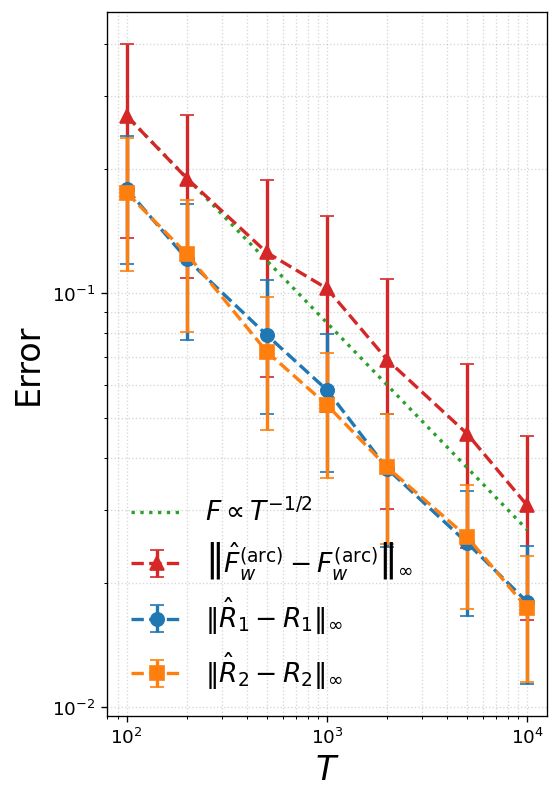

In [25]:
def plot_errors_vs_T_with_ref(
    T_list,
    noise_std=0.5,
    N_dense=5000,
    tau=0.05,
    n_rep=30,
    mode="balanced"
):
    mean_R1_err, std_R1_err = [], []
    mean_R2_err, std_R2_err = [], []
    mean_F_err, std_F_err = [], []

    for T_dataset in T_list:
        R1_list, R2_list, F_list = [], [], []

        for rep in range(n_rep):
            out = run_single_replication(
                T_dataset=T_dataset,
                noise_std=noise_std,
                N_dense=N_dense,
                tau=tau,
                seed=rep,
                mode=mode
            )
            R1_list.append(out["R1_err"])
            R2_list.append(out["R2_err"])
            F_list.append(out["F_err"])

        R1_list = np.array(R1_list)
        R2_list = np.array(R2_list)
        F_list = np.array(F_list)

        mean_R1_err.append(R1_list.mean())
        std_R1_err.append(R1_list.std())

        mean_R2_err.append(R2_list.mean())
        std_R2_err.append(R2_list.std())

        mean_F_err.append(F_list.mean())
        std_F_err.append(F_list.std())

    mean_R1_err = np.array(mean_R1_err)
    mean_R2_err = np.array(mean_R2_err)
    mean_F_err  = np.array(mean_F_err)

    std_R1_err = np.array(std_R1_err)
    std_R2_err = np.array(std_R2_err)
    std_F_err  = np.array(std_F_err)

    T_arr = np.array(T_list, dtype=float)


    # c1 = mean_R1_err[0] * np.sqrt(T_arr[0])
    # c2 = mean_R2_err[0] * np.sqrt(T_arr[0])
    cF = mean_F_err[0]  * np.sqrt(T_arr[0])

    # ref_R1 = c1 / np.sqrt(T_arr)
    # ref_R2 = c2 / np.sqrt(T_arr)
    ref_F  = cF / np.sqrt(T_arr)

    # ===== plot =====
    # plt.figure(figsize=(7, 5), dpi=120)kk
    plt.errorbar(
        T_list, mean_F_err, yerr=std_F_err,
        marker='^', linestyle='--', capsize=4,
        color='#d62728',
        label=r'$\left\|\hat{F}_w^{\rm (arc)} - {F}_w^{\rm (arc)}\right\|_\infty$'
    )
    plt.errorbar(
        T_list, mean_R1_err, yerr=std_R1_err,
        marker='o', linestyle='--', capsize=4,
        label=r'$\|\hat R_1-R_1\|_\infty$'
    )
    # plt.plot(T_arr, ref_R1, ':', label=r'$R_1 \propto T^{-1/2}$')

    plt.errorbar(
        T_list, mean_R2_err, yerr=std_R2_err,
        marker='s', linestyle='--', capsize=4,
        label=r'$\|\hat R_2-R_2\|_\infty$'
    )
    # plt.plot(T_arr, ref_R2, ':', label=r'$R_2 \propto T^{-1/2}$')

  
    plt.plot(T_arr, ref_F, ':', 
             label=r'$F \propto T^{-1/2}$')

    plt.xscale('log')
    plt.yscale('log')   
    plt.xlabel(r'$T$')
    plt.ylabel('Error')
    # plt.legend()
    plt.legend(loc='lower left', framealpha=0.9)
    plt.grid(True, which='both')
    plt.savefig("error_conv.pdf",bbox_inches='tight')
    plt.show()

    # Figure 2
T_list = [100, 200, 500, 1000, 2000, 5000, 10000]
results = plot_errors_vs_T_with_ref(
    T_list=T_list,
    noise_std=0.5,
    N_dense=1000,
    tau=tau,
    n_rep=100,
    mode="balanced"
)